# CIS 3120 Final Project Notebook

**Group 9 — Seismic Signals**  
**Topic:** USGS Earthquake API Analysis  

This notebook fetches earthquake data from the USGS Earthquake API, prepares the data using pandas, performs exploratory data analysis, and creates visualizations to answer the project research questions.

## Research Questions

1. What is the distribution of earthquake magnitudes over the selected time period?
2. Which regions experience the highest number of earthquakes?
3. How does earthquake depth correlate with magnitude?
4. How have earthquake frequencies changed over time?
5. What are the top 10 strongest earthquakes in the selected dataset, and where did they occur?
6. Are certain tectonic plate boundary regions associated with higher-magnitude earthquakes?

In [ ]:
# Import required libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Display settings for cleaner notebook output
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Fetch Data from the USGS Earthquake API

The project uses the USGS Earthquake API. The dataset includes worldwide seismic events with a minimum magnitude of 2.5 between January 1, 2026 and March 31, 2026.

In [ ]:
# API endpoint and query parameters
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {
    "format": "geojson",
    "starttime": "2026-01-01",
    "endtime": "2026-03-31",
    "minmagnitude": "2.5"
}

# Send request to API
response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
data = response.json()

print("Data retrieved successfully!")
print("Number of raw seismic events:", len(data["features"]))

Data retrieved successfully!
Number of raw seismic events: 6581


## 2. Convert API Data into a Pandas DataFrame

The API returns data in GeoJSON format. The code below extracts the location, magnitude, time, depth, longitude, latitude, and event type into a pandas DataFrame.

In [ ]:
rows = []

for q in data["features"]:
    prop = q["properties"]
    geo = q["geometry"]["coordinates"]

    rows.append({
        "place": prop["place"],
        "magnitude": prop["mag"],
        "time": pd.to_datetime(prop["time"], unit="ms"),
        "depth": geo[2],
        "longitude": geo[0],
        "latitude": geo[1],
        "event_type": prop["type"]
    })

df = pd.DataFrame(rows)

print("DataFrame shape:", df.shape)
df.head(10)

DataFrame shape: (6581, 7)


,place,magnitude,time,depth,longitude,latitude,event_type
0,"23 km WNW of Mentone, Texas",2.90,2026-03-30 23:38:29.274,8.5992,-103.837000,31.758000,earthquake
1,"157 km NNW of The Valley, Anguilla",3.44,2026-03-30 23:19:38.110,27.4800,-63.692500,19.509500,earthquake
2,"203 km S of Akhiok, Alaska",3.60,2026-03-30 23:04:35.606,18.2000,-154.550000,55.127000,earthquake
3,"3 km WSW of Lake Henshaw, CA",2.82,2026-03-30 22:51:28.720,14.5100,-116.790833,33.236167,earthquake
4,"121 km ESE of Bintuni, Indonesia",4.20,2026-03-30 22:35:27.616,10.0000,134.499300,-2.612500,earthquake
5,"Rat Islands, Aleutian Islands, Alaska",2.60,2026-03-30 22:30:51.416,31.4460,178.827200,51.287400,earthquake
6,Fiji region,4.20,2026-03-30 22:08:57.157,545.7100,-178.228900,-20.382600,earthquake
7,"13 km SSE of Gonzales, Texas",2.50,2026-03-30 21:38:09.851,7.0646,-97.415000,29.382000,earthquake
8,"43 km SW of Wales, Alaska",3.10,2026-03-30 20:23:31.196,10.0000,-168.785000,65.350000,earthquake
9,"48 km E of Luganville, Vanuatu",4.20,2026-03-30 19:58:25.574,130.2940,167.607900,-15.455900,earthquake


## 3. Exploratory Data Analysis

This section checks the dataset size, sample rows, missing values, summary statistics, event types, and the most common locations.

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
display(df.describe(include="all"))

print("\nEvent types:")
print(df["event_type"].value_counts())

print("\nTop 10 locations:")
print(df["place"].value_counts().head(10))

Shape: (6581, 7)

Missing values:
place         0
magnitude     0
time          0
depth         0
longitude     0
latitude      0
event_type    0
dtype: int64

Basic statistics:


,place,magnitude,time,depth,longitude,latitude,event_type
count,6581,6581.000000,6581,6581.000000,6581.000000,6581.000000,6581
unique,4905,NaN,NaN,NaN,NaN,NaN,4
top,south of the Fiji Islands,NaN,NaN,NaN,NaN,NaN,earthquake
freq,88,NaN,NaN,NaN,NaN,NaN,6541
mean,NaN,3.820414,2026-02-15 14:35:55.319852032,61.133887,-25.165153,24.879163,NaN
min,NaN,2.500000,2026-01-01 00:03:02.325000,-3.410000,-179.999700,-84.493200,NaN
25%,NaN,2.920000,2026-01-24 16:01:14.478000128,10.000000,-151.470000,1.377500,NaN
50%,NaN,4.100000,2026-02-16 16:28:48.465999872,14.360000,-69.305500,33.409400,NaN
75%,NaN,4.500000,2026-03-09 09:06:05.868000,61.100000,126.704800,52.063700,NaN
max,NaN,7.500000,2026-03-30 23:38:29.274000,667.197000,179.998900,83.755200,NaN



Event types:
event_type
earthquake          6541
mining explosion      38
explosion              1
quarry blast           1
Name: count, dtype: int64

Top 10 locations:
place
south of the Fiji Islands                88
South Sandwich Islands region            58
Mid-Indian Ridge                         50
south of the Kermadec Islands            45
Fiji region                              42
Rat Islands, Aleutian Islands, Alaska    34
Kermadec Islands region                  29
Izu Islands, Japan region                25
Kermadec Islands, New Zealand            25
Kuril Islands                            23
Name: count, dtype: int64


## 4. Data Cleaning and Preparation

The dataset includes a small number of non-earthquake events such as explosions, mining explosions, and quarry blasts. These are removed so the analysis focuses only on actual earthquakes.

In [ ]:
# Keep only actual earthquakes and remove rows missing important numerical values
df_clean = df[df["event_type"] == "earthquake"].copy()
df_clean = df_clean.dropna(subset=["magnitude", "depth", "time", "place"])

# Create a simplified region column from the place field
def extract_region(place):
    if pd.isna(place):
        return "Unknown"
    parts = str(place).split(",")
    return parts[-1].strip() if len(parts) > 1 else str(place).strip()

df_clean["region"] = df_clean["place"].apply(extract_region)
df_clean["date"] = df_clean["time"].dt.date

print("Original rows:", len(df))
print("Cleaned earthquake rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

df_clean.head(10)

Original rows: 6581
Cleaned earthquake rows: 6541
Rows removed: 40


,place,magnitude,time,depth,longitude,latitude,event_type,region,date
0,"23 km WNW of Mentone, Texas",2.90,2026-03-30 23:38:29.274,8.5992,-103.837000,31.758000,earthquake,Texas,2026-03-30
1,"157 km NNW of The Valley, Anguilla",3.44,2026-03-30 23:19:38.110,27.4800,-63.692500,19.509500,earthquake,Anguilla,2026-03-30
2,"203 km S of Akhiok, Alaska",3.60,2026-03-30 23:04:35.606,18.2000,-154.550000,55.127000,earthquake,Alaska,2026-03-30
3,"3 km WSW of Lake Henshaw, CA",2.82,2026-03-30 22:51:28.720,14.5100,-116.790833,33.236167,earthquake,CA,2026-03-30
4,"121 km ESE of Bintuni, Indonesia",4.20,2026-03-30 22:35:27.616,10.0000,134.499300,-2.612500,earthquake,Indonesia,2026-03-30
5,"Rat Islands, Aleutian Islands, Alaska",2.60,2026-03-30 22:30:51.416,31.4460,178.827200,51.287400,earthquake,Alaska,2026-03-30
6,Fiji region,4.20,2026-03-30 22:08:57.157,545.7100,-178.228900,-20.382600,earthquake,Fiji region,2026-03-30
7,"13 km SSE of Gonzales, Texas",2.50,2026-03-30 21:38:09.851,7.0646,-97.415000,29.382000,earthquake,Texas,2026-03-30
8,"43 km SW of Wales, Alaska",3.10,2026-03-30 20:23:31.196,10.0000,-168.785000,65.350000,earthquake,Alaska,2026-03-30
9,"48 km E of Luganville, Vanuatu",4.20,2026-03-30 19:58:25.574,130.2940,167.607900,-15.455900,earthquake,Vanuatu,2026-03-30


## Question 1: Magnitude Distribution

This histogram shows how often different earthquake magnitudes occurred in the cleaned dataset.

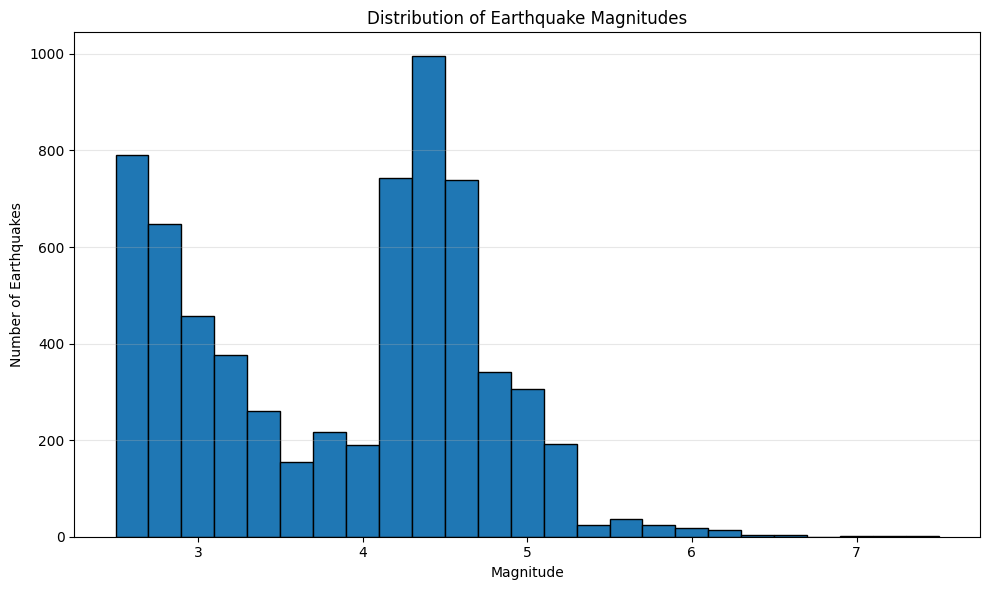

Most earthquakes in the dataset are lower-magnitude events. Stronger earthquakes occur much less frequently.


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["magnitude"], bins=25, edgecolor="black")
plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Most earthquakes in the dataset are lower-magnitude events. Stronger earthquakes occur much less frequently.")

## Question 2: Regions with the Most Earthquakes

This bar chart groups earthquakes by the simplified region field and shows the top 10 most active regions.

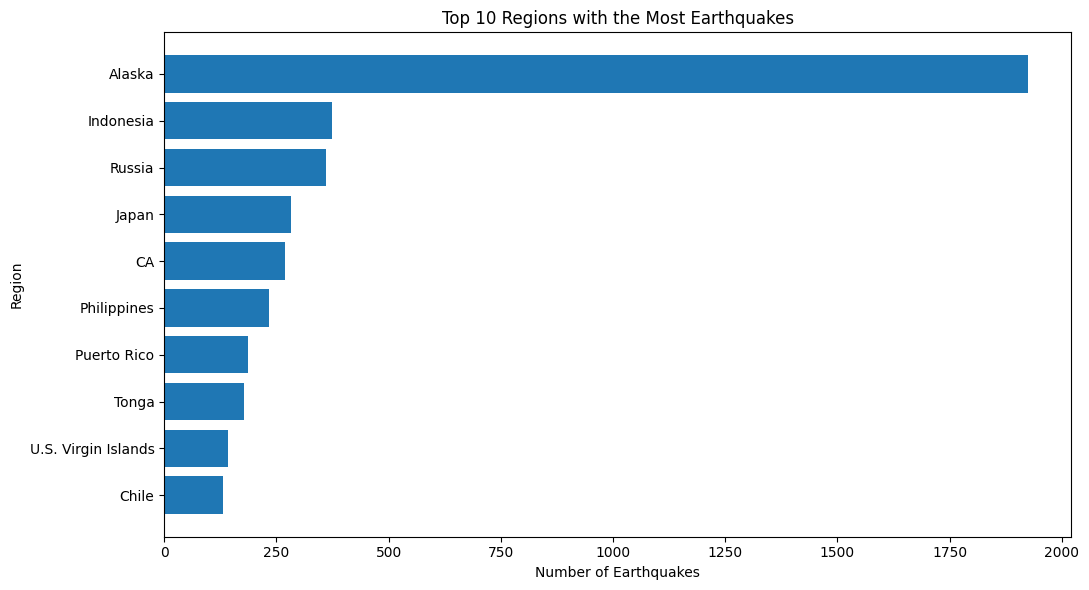

Top 10 earthquake regions:


,count,count
0,Alaska,1925
1,Indonesia,375
2,Russia,361
3,Japan,282
4,CA,269
5,Philippines,234
6,Puerto Rico,186
7,Tonga,177
8,U.S. Virgin Islands,143
9,Chile,131


In [ ]:
region_counts = df_clean["region"].value_counts().head(10).sort_values()

plt.figure(figsize=(11, 6))
plt.barh(region_counts.index, region_counts.values)
plt.title("Top 10 Regions with the Most Earthquakes")
plt.xlabel("Number of Earthquakes")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

print("Top 10 earthquake regions:")
display(df_clean["region"].value_counts().head(10).reset_index().rename(columns={"index": "region", "region": "count"}))

## Question 3: Depth vs. Magnitude

This scatter plot compares earthquake depth in kilometers with magnitude. It helps determine whether deeper earthquakes tend to be stronger or weaker.

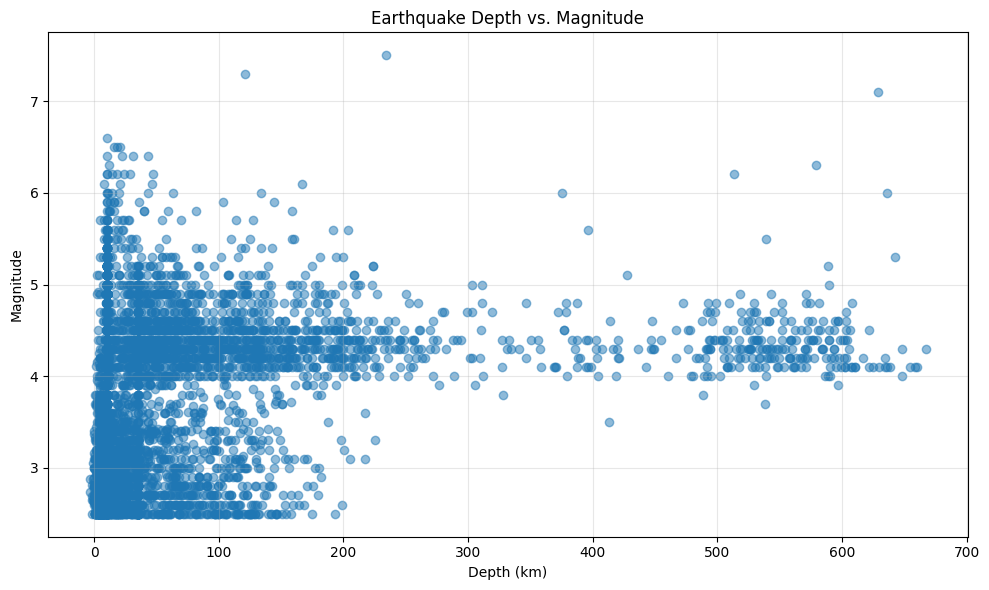

Correlation between depth and magnitude: 0.197
A correlation near 0 means there is no strong linear relationship between earthquake depth and magnitude in this dataset.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["depth"], df_clean["magnitude"], alpha=0.5)
plt.title("Earthquake Depth vs. Magnitude")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

correlation = df_clean["depth"].corr(df_clean["magnitude"])
print(f"Correlation between depth and magnitude: {correlation:.3f}")
print("A correlation near 0 means there is no strong linear relationship between earthquake depth and magnitude in this dataset.")

## Question 4: Earthquake Frequency Over Time

This line chart shows the number of earthquakes recorded each day during the selected time period.

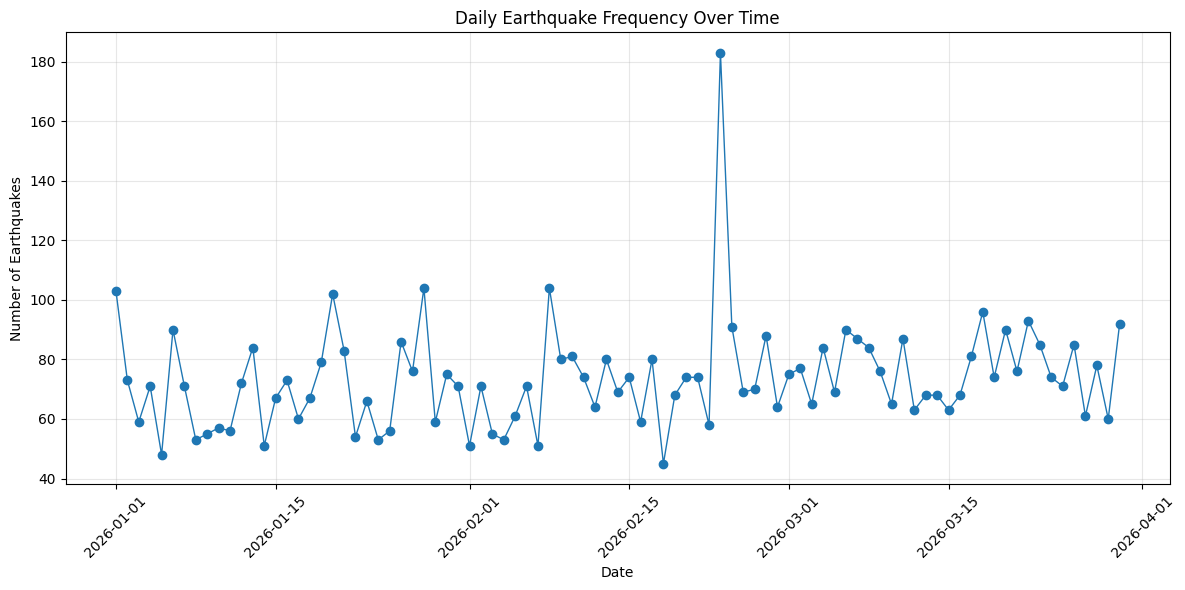

Daily earthquake counts:


,date,earthquake_count
0,2026-01-01,103
1,2026-01-02,73
2,2026-01-03,59
3,2026-01-04,71
4,2026-01-05,48
5,2026-01-06,90
6,2026-01-07,71
7,2026-01-08,53
8,2026-01-09,55
9,2026-01-10,57


In [ ]:
daily_earthquakes = df_clean.groupby("date").size().reset_index(name="earthquake_count")

plt.figure(figsize=(12, 6))
plt.plot(daily_earthquakes["date"], daily_earthquakes["earthquake_count"], marker="o", linewidth=1)
plt.title("Daily Earthquake Frequency Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Earthquakes")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Daily earthquake counts:")
display(daily_earthquakes.head(10))

## Question 5: Top 10 Strongest Earthquakes

This section identifies the 10 strongest earthquakes by magnitude and displays them in both table and bar chart form.

,place,magnitude,depth,time,latitude,longitude
510,"158 km W of Neiafu, Tonga",7.5,234.000,2026-03-24 04:37:51.627,-18.5387,-175.4763
51,"51 km ENE of Luganville, Vanuatu",7.3,120.628,2026-03-30 08:44:13.780,-15.2865,167.5825
2881,"57 km NNW of Kota Belud, Malaysia",7.1,629.000,2026-02-22 16:57:46.738,6.8541,116.2942
735,northern Mid-Atlantic Ridge,6.6,10.000,2026-03-21 12:16:46.629,23.8601,-45.7987
6445,"0 km W of San Marcos, Mexico",6.5,18.000,2026-01-02 13:58:15.741,16.7980,-99.3939
325,"123 km E of Yamada, Japan",6.5,16.000,2026-03-26 14:18:51.927,39.4377,143.3826
864,South Shetland Islands,6.5,21.000,2026-03-20 00:22:04.661,-61.1875,-56.4033
2023,"223 km ESE of Attu Station, Alaska",6.4,10.000,2026-03-04 17:54:36.723,52.3258,176.3707
5910,"247 km SE of Sarangani, Philippines",6.4,31.000,2026-01-10 14:58:23.726,3.7767,126.9922
6121,"35 km E of Santiago, Philippines",6.4,22.000,2026-01-07 03:02:53.890,7.2449,126.8953


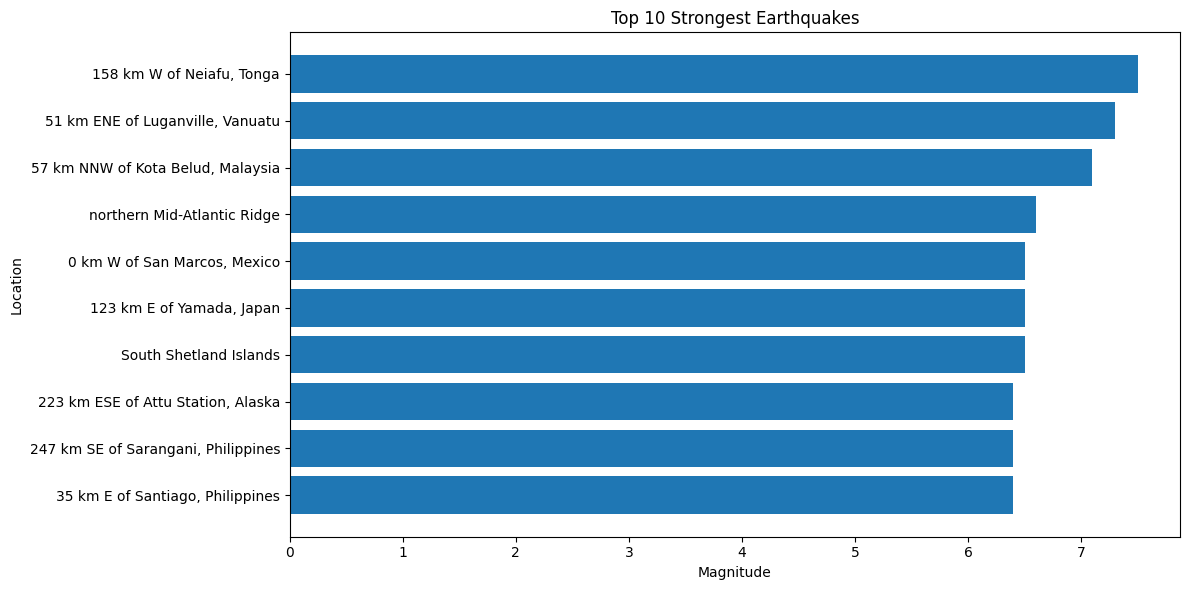

The strongest earthquakes are concentrated in known seismically active regions, many of which are associated with tectonic plate boundaries.


In [ ]:
top_10_strongest = df_clean.sort_values(by="magnitude", ascending=False).head(10).copy()
top_10_strongest_display = top_10_strongest[["place", "magnitude", "depth", "time", "latitude", "longitude"]]

display(top_10_strongest_display)

plt.figure(figsize=(12, 6))
plt.barh(top_10_strongest["place"], top_10_strongest["magnitude"])
plt.title("Top 10 Strongest Earthquakes")
plt.xlabel("Magnitude")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("The strongest earthquakes are concentrated in known seismically active regions, many of which are associated with tectonic plate boundaries.")

## Question 6: Tectonic Plate Boundary Interpretation

A full tectonic plate boundary overlay would require combining the USGS earthquake dataset with an additional tectonic plate boundary dataset. For this project, the location results still show that many of the most active and strongest earthquake regions are in known seismically active areas such as Fiji, Tonga, the Kermadec Islands, the South Sandwich Islands, and Alaska's Aleutian region. These areas are commonly associated with plate boundary activity.

Because of time and data scope, this part is treated as an interpretation based on earthquake locations rather than a separate merged dataset.

## Final Conclusions

The USGS Earthquake API provided a clean and useful dataset for analyzing worldwide earthquake activity. After filtering out non-earthquake events, the project found that most earthquakes in the selected period were lower-magnitude events, while high-magnitude earthquakes were much rarer. Earthquakes were not evenly spread across the world; instead, activity was concentrated in specific regions that are commonly associated with tectonic plate boundaries.

The depth vs. magnitude scatter plot did not show a strong linear relationship, meaning earthquake depth alone did not clearly predict earthquake strength in this dataset. The time-series analysis showed how earthquake frequency changed day by day during the selected period. Overall, the project demonstrates how API data can be collected, cleaned, analyzed, and visualized using Python, pandas, and matplotlib.